In [68]:
import pandas as pd

In [69]:
#Phase 1 — Data Understanding
#Load the dataset with Pandas
df=pd.read_csv("spamham.csv",sep="\t",names=['label','message'])

In [70]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [71]:

#Check shape
df.shape


(5572, 2)

In [72]:
#Check missing values
df.isnull().sum()

label      0
message    0
dtype: int64

In [73]:
#Check duplicate messages
df.duplicated().sum()

np.int64(403)

In [74]:
df=df.drop_duplicates()

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.shape

(5169, 2)

In [77]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

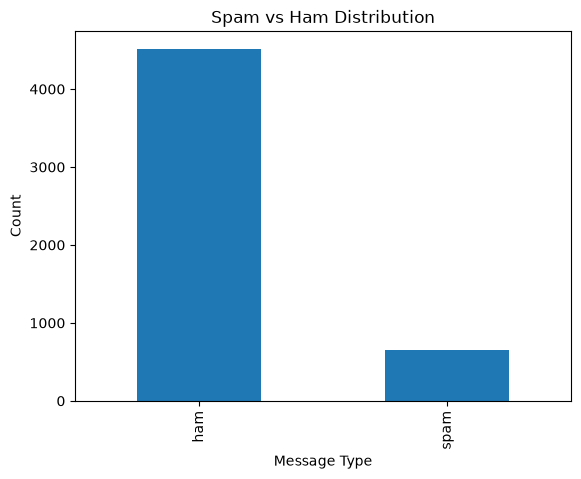

In [78]:
#Check spam vs ham distribution
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [79]:
y=df['label'].map({'ham':1,'spam':0})

In [80]:
y.value_counts()

label
1    4516
0     653
Name: count, dtype: int64

In [81]:
x=df['message']

In [82]:
import nltk
from nltk.corpus import stopwords
from nltk import sent_tokenize,word_tokenize
from gensim.utils import simple_preprocess

In [83]:

from nltk.stem import WordNetLemmatizer
lemma=nltk.WordNetLemmatizer()

words = []
stop_words = set(stopwords.words("english"))

for sentence in x:

    word = simple_preprocess(sentence)

    change_word = [
        lemma.lemmatize(w)
        for w in word
        if w not in stop_words
    ]

    word = " ".join(change_word)

    words.append(word)

print("Number of messages:", len(words))

Number of messages: 5169


In [84]:
len(words)

5169

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the text first
x_train_text, x_test_text, y_train, y_test = train_test_split(
    words,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create TF-IDF
tfidf = TfidfVectorizer()

# Fit ONLY on training data
x_train = tfidf.fit_transform(x_train_text)

# Transform test data using the same TF-IDF
x_test = tfidf.transform(x_test_text)

print(x_train.shape)
print(x_test.shape)

(4135, 6203)
(1034, 6203)


In [86]:
from sklearn.naive_bayes import MultinomialNB
bayes=MultinomialNB()
bayes.fit(x_train,y_train)
y_pred=bayes.predict(x_test)
print(y_pred)

[1 1 1 ... 1 1 1]


In [87]:
from sklearn.metrics import accuracy_score,classification_report
print("accuracy_score",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred,target_names=['spam', 'ham']))
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

accuracy_score 0.9680851063829787
classification report:               precision    recall  f1-score   support

        spam       1.00      0.75      0.86       131
         ham       0.96      1.00      0.98       903

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034

[[ 98  33]
 [  0 903]]


In [88]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

for alpha in [0.01, 0.1, 0.5, 1.0, 2.0]:

    bayes = MultinomialNB(alpha=alpha)

    bayes.fit(x_train, y_train)

    y_pred = bayes.predict(x_test)

    print("Alpha:", alpha)
    print(classification_report(
        y_test,
        y_pred,
        target_names=['spam', 'ham']
    ))

Alpha: 0.01
              precision    recall  f1-score   support

        spam       0.94      0.91      0.92       131
         ham       0.99      0.99      0.99       903

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034

Alpha: 0.1
              precision    recall  f1-score   support

        spam       0.94      0.89      0.92       131
         ham       0.98      0.99      0.99       903

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Alpha: 0.5
              precision    recall  f1-score   support

        spam       0.99      0.81      0.89       131
         ham       0.97      1.00      0.99       903

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.98      0.97      0

In [96]:
from sklearn.naive_bayes import MultinomialNB

bayes = MultinomialNB(alpha=0.01)

bayes.fit(x_train, y_train)

y_pred = bayes.predict(x_test)

In [97]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=['spam', 'ham']
))

Accuracy: 0.9806576402321083
              precision    recall  f1-score   support

        spam       0.94      0.91      0.92       131
         ham       0.99      0.99      0.99       903

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [91]:
new_sms = ["URGENT! You have been selected to receive a cash bonus."]

new_words = []

for sentence in new_sms:

    word = simple_preprocess(sentence)

    change_word = [
        lemma.lemmatize(w)
        for w in word
        if w not in stop_words
    ]

    word = " ".join(change_word)

    new_words.append(word)

new_vector = tfidf.transform(new_words)

prediction = bayes.predict(new_vector)

if prediction[0] == 0:
    print("Spam 🚨")
else:
    print("Ham ✅")

Spam 🚨


In [92]:
print(prediction)
print(new_words)

[0]
['urgent selected receive cash bonus']


In [93]:
print("Original:", new_sms)
print("Processed:", new_words)

print("Prediction:", prediction)

print("Spam probability:", bayes.predict_proba(new_vector))

Original: ['URGENT! You have been selected to receive a cash bonus.']
Processed: ['urgent selected receive cash bonus']
Prediction: [0]
Spam probability: [[0.99505652 0.00494348]]


In [94]:
new_sms2= ["hi essha..how are you.. are you okay now !"]
new_word2=[]
for sentence2 in new_sms2:
    change_process2=simple_preprocess(sentence2)
    change_word2=[lemma.lemmatize(w)
                 for w in change_process2
                 if w not in stop_words]
    word2=" ".join(change_word2)
    new_word2.append(word2)
new_vector2=tfidf.transform(new_word2)
prediction2=bayes.predict(new_vector2)
if prediction2[0]==0:
   print("spam")
else:
    print("ham")

ham
